# Proyek 4B

Kelompok 10
Anggota:
- Andrea Verlina (222200103 / IBDA 2022)
- Brygitta Josefien (222102260 / IBDA 2022)
- Chaterine Laurent (222101405 /   CFP  2022)
- Elaine Evelyn (222102311 / IBDA 2022)
- Elizabeth Lovena (222101873 / IBDA 2022)

In [620]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from scipy.stats import norm
import scipy.stats as stat
import pylab 

import warnings
warnings.filterwarnings('ignore')

In [621]:
data = pd.read_csv('Life Expectancy Data.csv')
display(data)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64

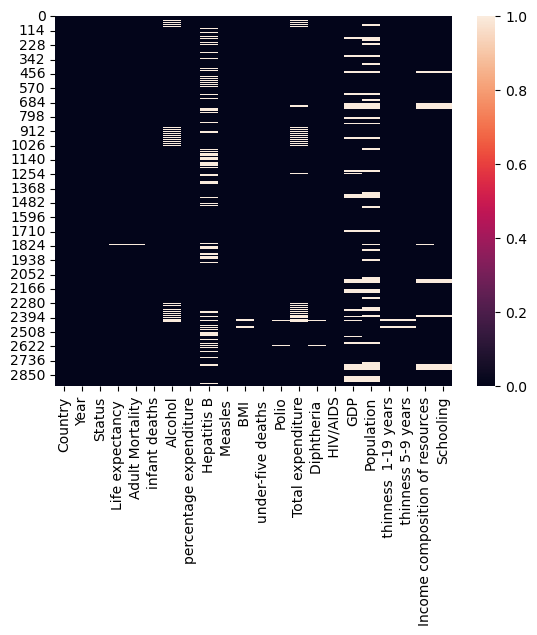

In [622]:
# heatmap that shows where are missing data
sns.heatmap(pd.isnull(data))
data.isnull().sum()

In [623]:
data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

# rows
print(data.shape[0])

1649


In [624]:
data.isnull().sum()

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64

In [625]:
data = data[['Alcohol', 'percentage expenditure', ' BMI ', 'Hepatitis B', 'Life expectancy ', 'Status', 'Country']]

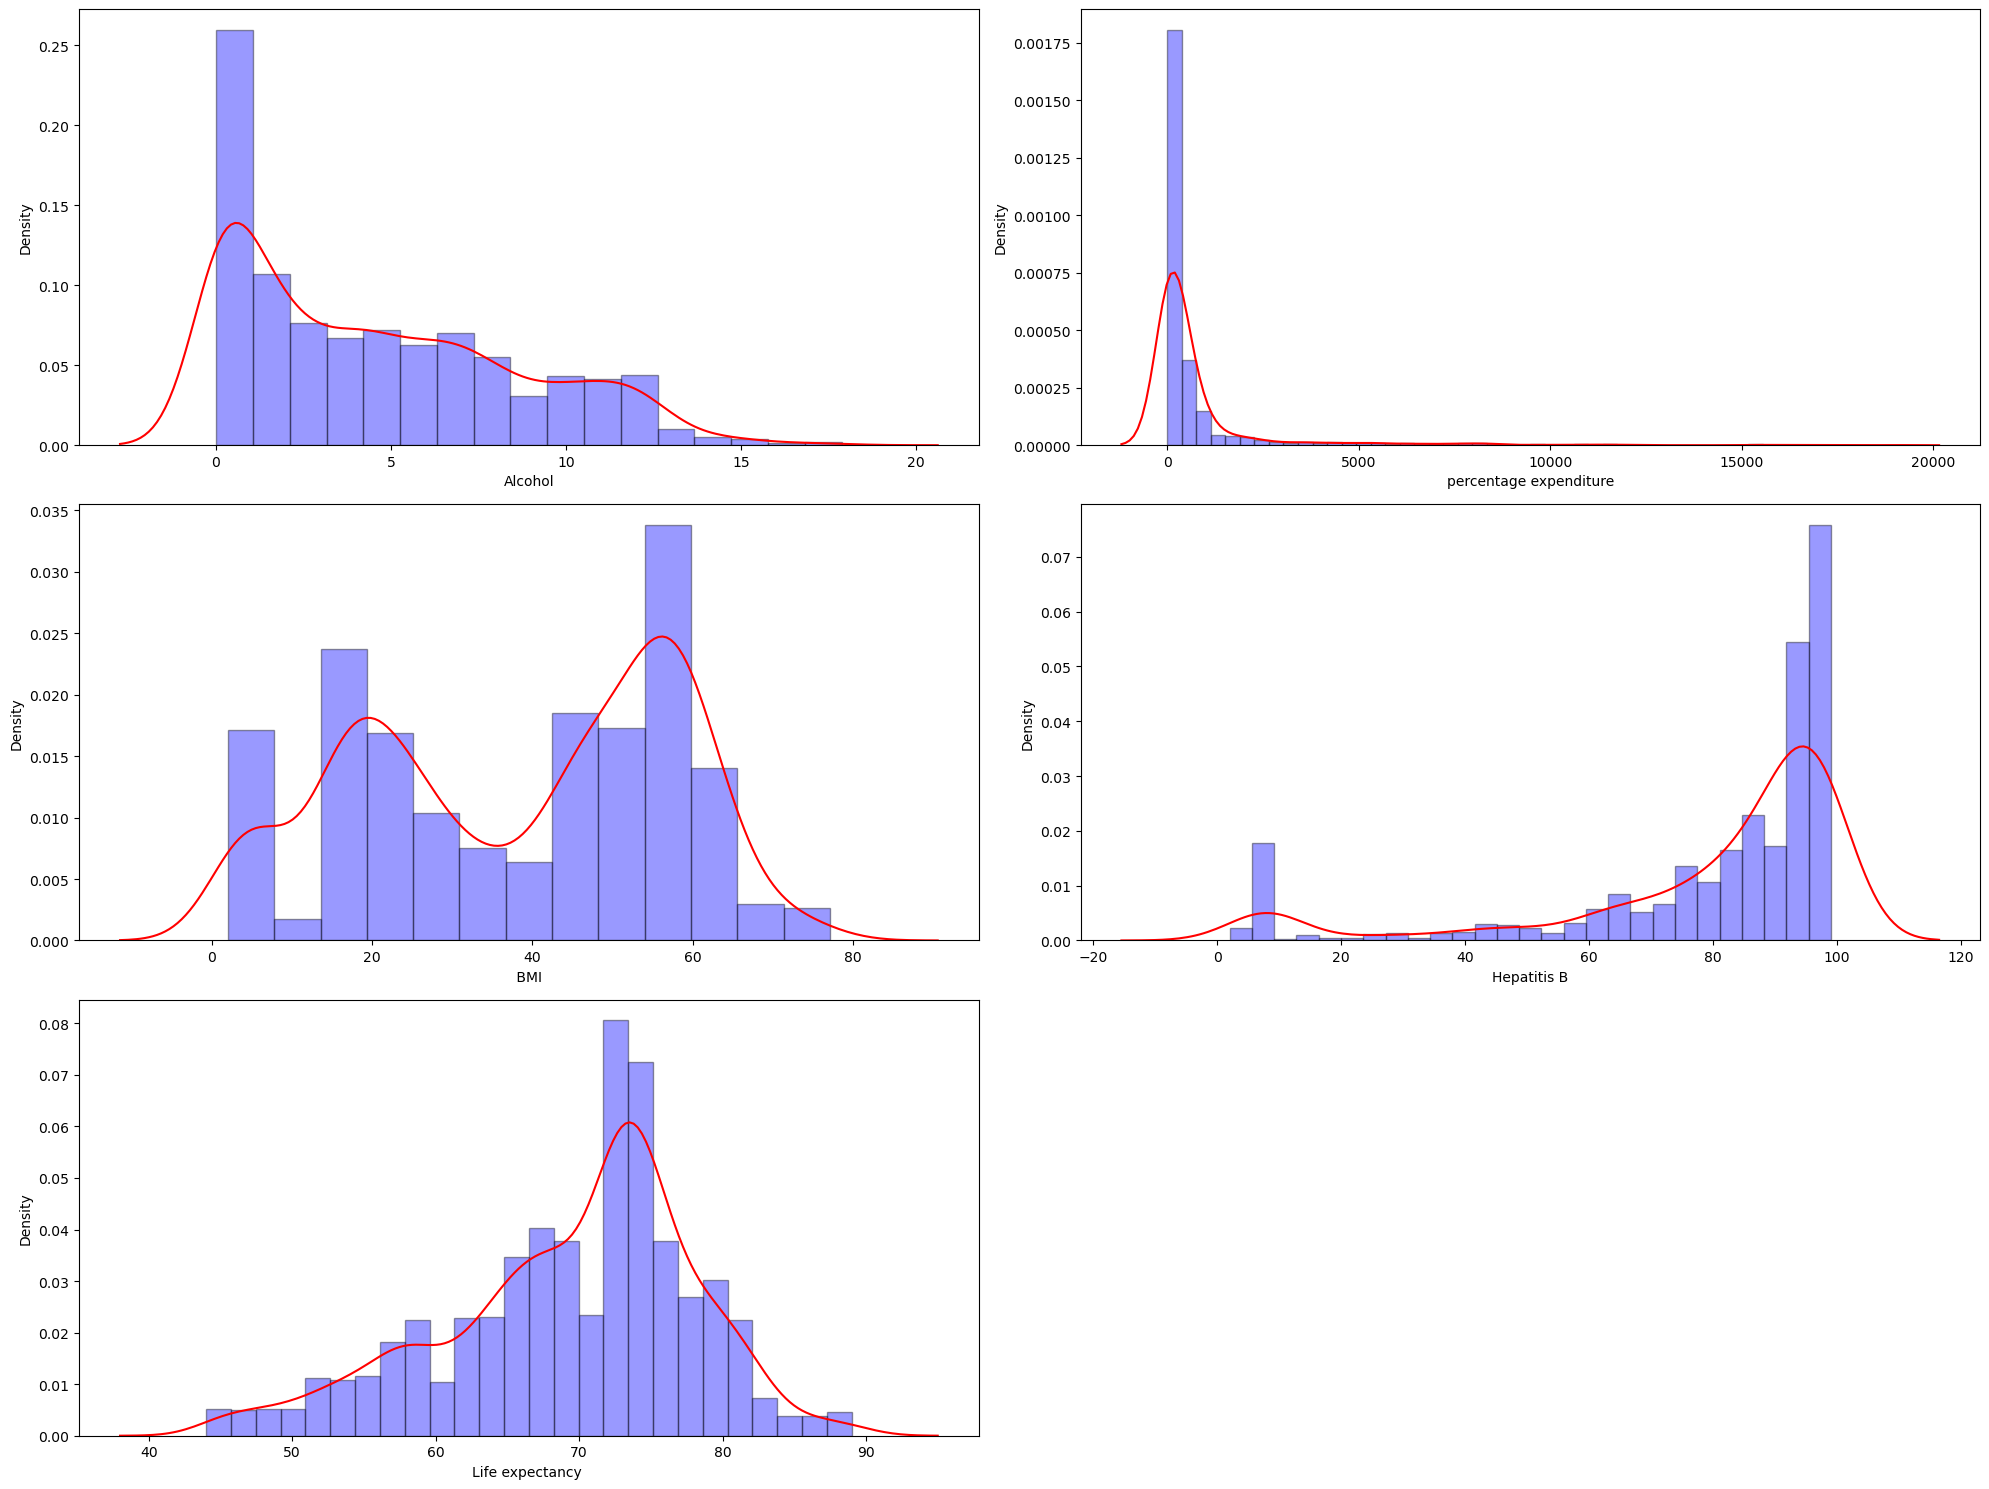

In [626]:
import warnings
warnings.simplefilter(action='ignore')

count = 1

fig = plt.figure(figsize = [20, 15])  # Adjust the figure size if necessary

for col in data.columns:
    if col!='Status' and col!='Country':
        plt.subplot(3, 2, count)  # Change the subplot dimensions here
        sns.distplot(data[col], hist_kws=dict(edgecolor="k", linewidth=1, color='blue'), color='red')
        count += 1
plt.tight_layout()
plt.show()

In [627]:
print("Total 0 value outliers in Alcohol: ", data[data['Alcohol'] == 0].shape[0])
print("Total 0 value outliers in Percentage Expenditure: ", data[data['percentage expenditure'] == 0].shape[0])
print("Total 0 value outliers in BMI: ", data[data[' BMI '] == 0].shape[0])
print("Total 0 value outliers in Hepatitis B: ", data[data['Hepatitis B'] == 0].shape[0])
print("Total 0 value outliers in Life Expectancy: ", data[data['Life expectancy '] == 0].shape[0])

Total 0 value outliers in Alcohol:  0
Total 0 value outliers in Percentage Expenditure:  5
Total 0 value outliers in BMI:  0
Total 0 value outliers in Hepatitis B:  0
Total 0 value outliers in Life Expectancy:  0


In [628]:
data['percentage expenditure'] = data['percentage expenditure'].replace(0, 0.001)

In [629]:
data.describe()

,Alcohol,percentage expenditure,BMI,Hepatitis B,Life expectancy
count,1649.000000,1649.000000,1649.000000,1649.000000,1649.000000
mean,4.533196,698.973561,38.128623,79.217708,69.302304
std,4.029189,1759.229335,19.754249,25.604664,8.796834
min,0.010000,0.001000,2.000000,2.000000,44.000000
25%,0.810000,37.438577,19.500000,74.000000,64.400000
50%,3.790000,145.102253,43.700000,89.000000,71.700000
75%,7.340000,509.389994,55.800000,96.000000,75.000000
max,17.870000,18961.348600,77.100000,99.000000,89.000000


Developed Countries:	19
Developing Countries:	114


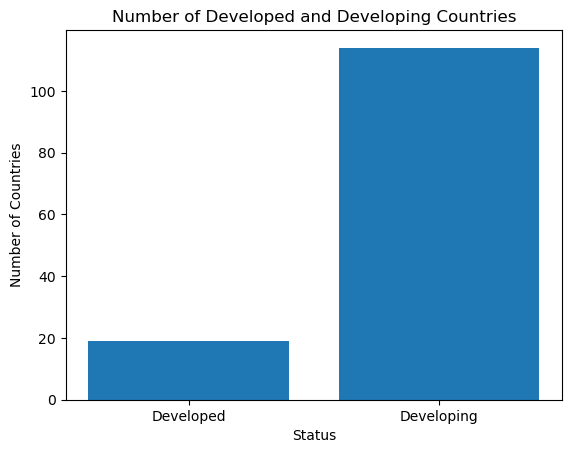

In [630]:
# show how many country is a developing/developed country from 193 country
developed_countries = data[data['Status'] == 'Developed']['Country'].nunique()
print(f"Developed Countries:\t{developed_countries}")

# developing
developing_countries = data[data['Status'] == 'Developing']['Country'].nunique()
print(f"Developing Countries:\t{developing_countries}")

plt.bar(['Developed', 'Developing'], [developed_countries, developing_countries])

# Add labels and title
plt.xlabel('Status')
plt.ylabel('Number of Countries')
plt.title('Number of Developed and Developing Countries')

# Show the plot
plt.show()

## Masalah 1

Bagaimanakah relasi antara masing-masing aspek dengan besarnya life expectancy? Apakah linear, eksponensial, logaritmik, resiprokal, atau lainnya?

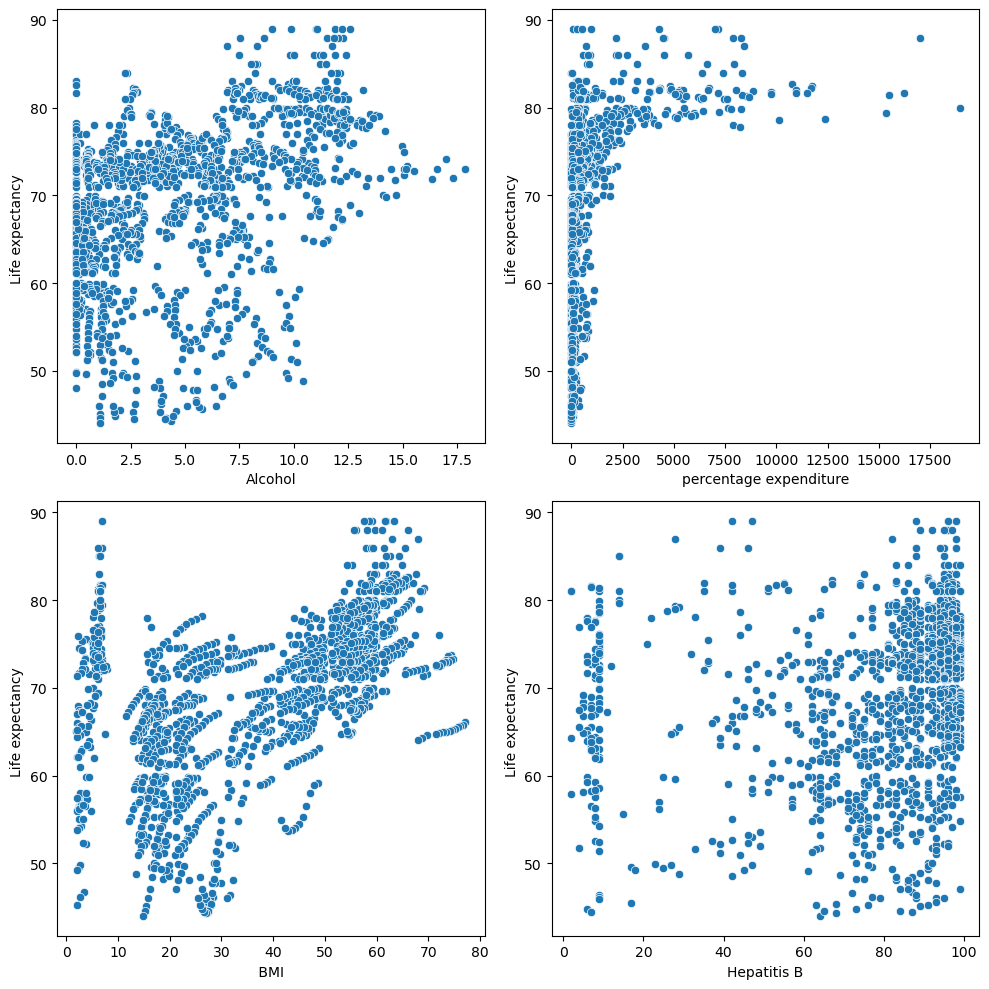

In [631]:
plt.figure(figsize=(10, 10))
for col in range(1,len(data.columns)):
    if col != 5 and col != 6:
        plt.subplot(2, 2, col)
        sns.scatterplot(data, x = data.columns[col - 1], y = 'Life expectancy ')
plt.tight_layout()
plt.show()

In [632]:
def plot_data(df,feature):
    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    df[feature].hist()
    plt.subplot(1,2,2)
    stat.probplot(df[feature],dist='norm',plot=pylab)
    plt.show()

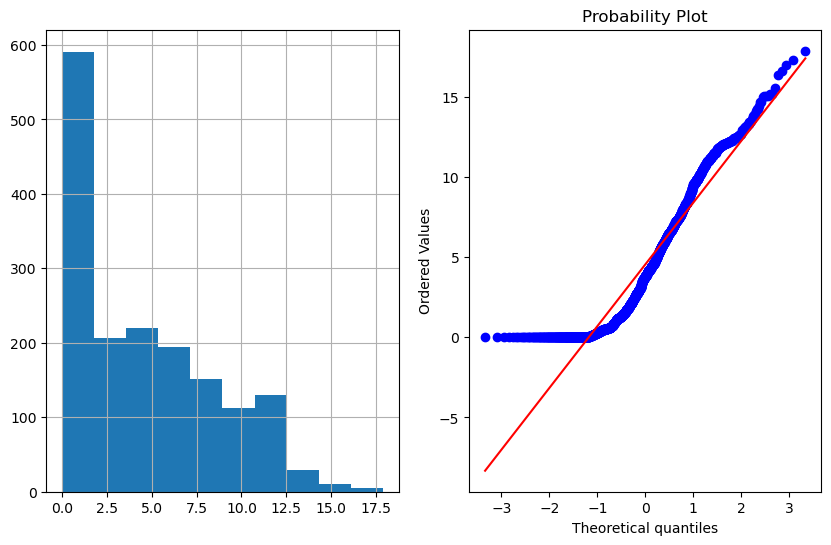

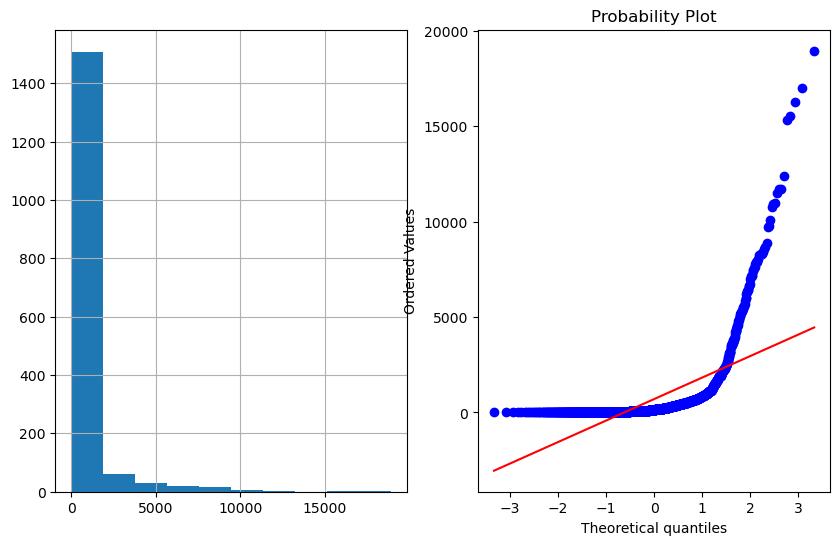

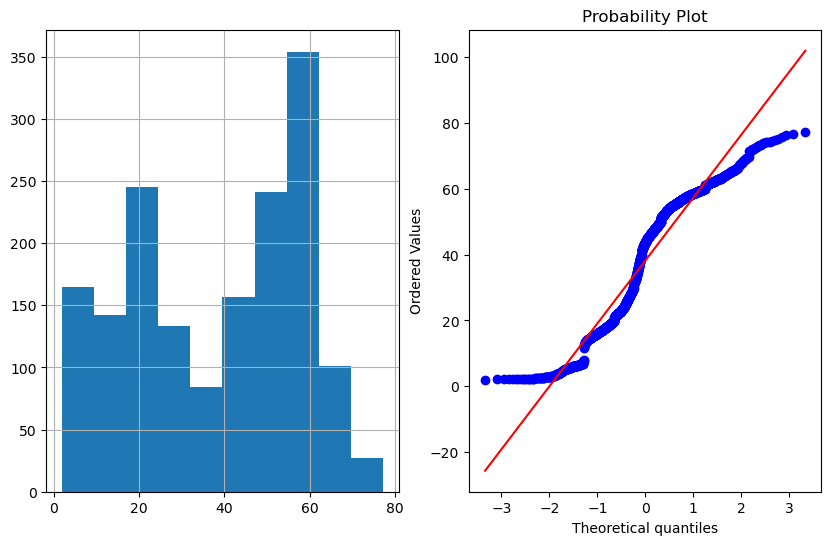

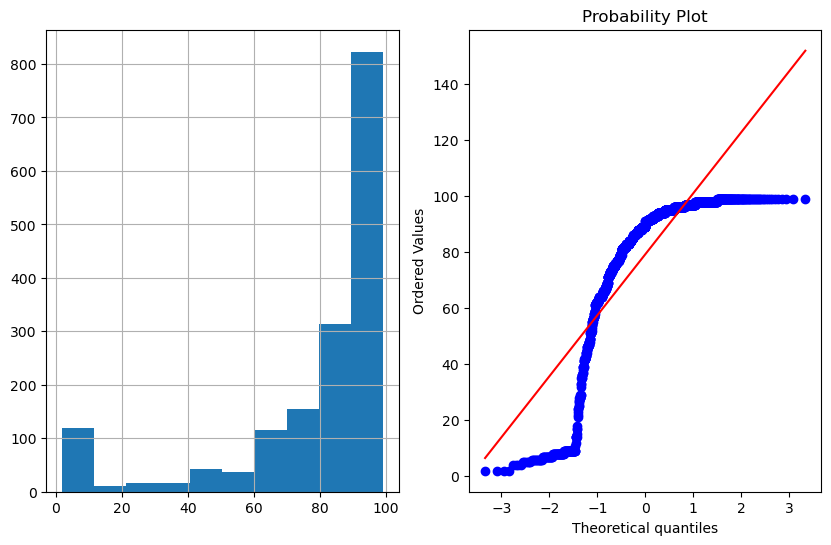

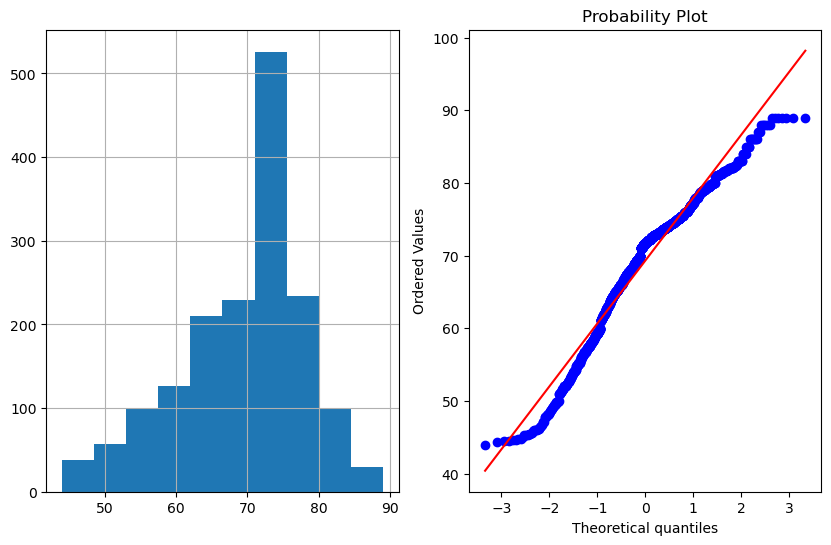

In [633]:
plot_data(data,'Alcohol')
plot_data(data,'percentage expenditure')
plot_data(data,' BMI ')
plot_data(data,'Hepatitis B')
plot_data(data,'Life expectancy ')


In [634]:
# konsumsi alkohol per kapita
alcohol = np.array(data['Alcohol'].tolist())
# print(np.size(alchohol))

# persentase belanja negara (expenditure) terkait kesehatan dibandingkan keseluruhan GDP
percentage_expenditure = np.array(data['percentage expenditure'].tolist())
# print(np.size(percentage_expenditure))

# Rataan BMI (Body Mass Index) penduduk
bmi = np.array(data[' BMI '].tolist())
# print(np.size(bmi))

# persentase imunisasi hepatitis
hepatitis_b = np.array(data['Hepatitis B'].tolist())
# print(np.size(hepatitis_b))

# life expectancy
life_expectancy = np.array(data['Life expectancy '].tolist())

n = np.size(life_expectancy)
# print(n)

## Masalah 2

Bila relevan, buatlah model regresi linear sederhana untuk hubungan antara masing-masing aspek dengan life expectancy. Berikan evaluasi kecocokan modelnya.

In [635]:
def reg_linear(x, y, feature):
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    Sxx = np.sum((x-x_bar)**2)
    Sxy = np.sum((x-x_bar)*(y-y_bar))
    Syy = np.sum((y-y_bar)**2)

    print(f"Rataan x \t: {x_bar: .3f}")
    print(f"Rataan y \t: {y_bar: .3f}")
    print(f"Simpangan xx \t: {Sxx: .3f}")
    print(f"Simpangan xy \t: {Sxy: .3f}")
    print(f"Simpangan yy \t: {Syy: .3f}")

    b1 = Sxy/Sxx
    b0 = y_bar-b1*x_bar

    print(f"Nilai b0 \t: {b0: .3f}")
    print(f"Nilai b1 \t: {b1: .3f}")

    x_line = np.linspace(np.min(x), np.max(x), 100)
    y_line = b0 + b1 * x_line

    y_hat = b0 + b1 * x

    SSE = np.sum((y_hat - y)**2)
    SSR = np.sum((y_hat - y_bar)**2)
    SST = SSE + SSR

    print(f"SSE \t: {SSE: .3f}")
    print(f"SSR \t: {SSR: .3f}")
    print(f"SST \t: {SST: .3f}")

    rho = Sxy/np.sqrt(Sxx*Syy)
    R_square = rho**2
    MSE = 1/(n-2) * np.sum((y_hat-y)**2)
    RMSE = np.sqrt(MSE)

    print(f"rho \t: {rho: .3f}")
    print(f"R2 \t: {R_square: .3f}")
    print(f"MSE \t: {MSE: .3f}")
    print(f"RMSE \t: {RMSE: .3f}")

    plt.plot(x_line, y_line, label = "model", c = "red")

    plt.scatter(x, y, label = "data", c = "purple")

    plt.xlabel(f"{feature}")
    plt.ylabel("Life Expectancy")
    plt.title(f"Relationship between {feature} and Life Expectancy")
    plt.legend()
    plt.show()

Rataan x 	:  4.533
Rataan y 	:  69.302
Simpangan xx 	:  26754.232
Simpangan xy 	:  23523.538
Simpangan yy 	:  127529.311
Nilai b0 	:  65.317
Nilai b1 	:  0.879
SSE 	:  106846.347
SSR 	:  20682.965
SST 	:  127529.311
rho 	:  0.403
R2 	:  0.162
MSE 	:  64.873
RMSE 	:  8.054


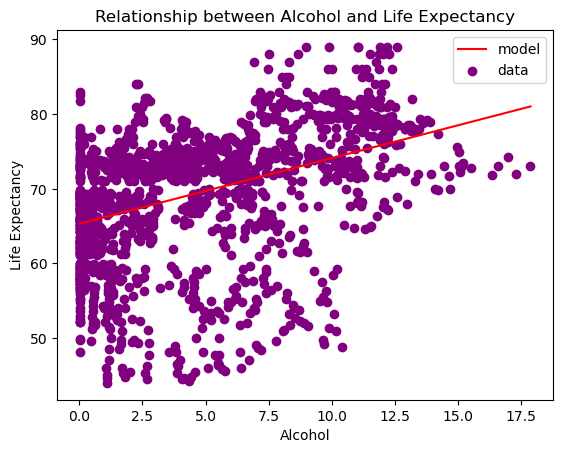

In [636]:
reg_linear(alcohol, life_expectancy, "Alcohol")

Rataan x 	:  698.974
Rataan y 	:  69.302
Simpangan xx 	:  5100375182.774
Simpangan xy 	:  10447170.764
Simpangan yy 	:  127529.311
Nilai b0 	:  67.871
Nilai b1 	:  0.002
SSE 	:  106130.223
SSR 	:  21399.088
SST 	:  127529.311
rho 	:  0.410
R2 	:  0.168
MSE 	:  64.439
RMSE 	:  8.027


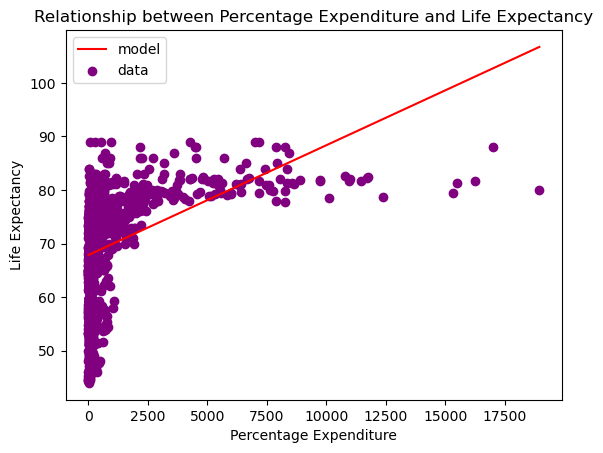

Rataan x 	:  4.836
Rataan y 	:  4.230
Simpangan xx 	:  7134.691
Simpangan xy 	:  244.937
Simpangan yy 	:  30.016
Nilai b0 	:  4.064
Nilai b1 	:  0.034
SSE 	:  21.607
SSR 	:  8.409
SST 	:  30.016
rho 	:  0.529
R2 	:  0.280
MSE 	:  0.013
RMSE 	:  0.115


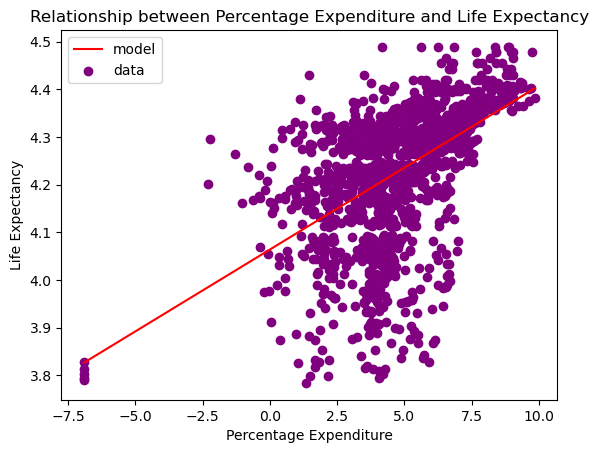

In [637]:
reg_linear(percentage_expenditure, life_expectancy, "Percentage Expenditure")
reg_linear(np.log(percentage_expenditure), np.log(life_expectancy), "Percentage Expenditure") #better r2

Rataan x 	:  38.129
Rataan y 	:  69.302
Simpangan xx 	:  643099.649
Simpangan xy 	:  155230.391
Simpangan yy 	:  127529.311
Nilai b0 	:  60.099
Nilai b1 	:  0.241
SSE 	:  90060.041
SSR 	:  37469.270
SST 	:  127529.311
rho 	:  0.542
R2 	:  0.294
MSE 	:  54.681
RMSE 	:  7.395


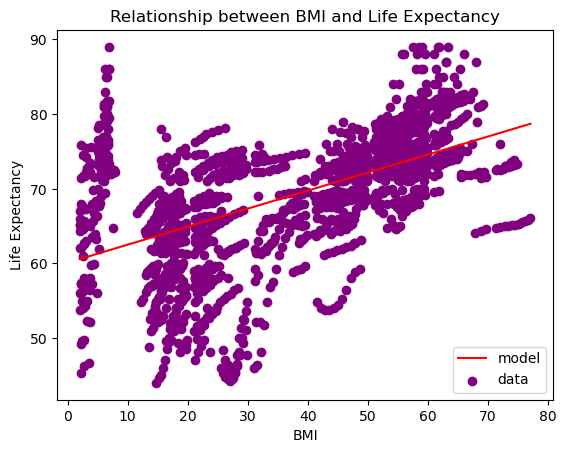

In [638]:
reg_linear(bmi, life_expectancy, "BMI")

Rataan x 	:  79.218
Rataan y 	:  69.302
Simpangan xx 	:  1080426.843
Simpangan xy 	:  74215.073
Simpangan yy 	:  127529.311
Nilai b0 	:  63.861
Nilai b1 	:  0.069
SSE 	:  122431.440
SSR 	:  5097.871
SST 	:  127529.311
rho 	:  0.200
R2 	:  0.040
MSE 	:  74.336
RMSE 	:  8.622


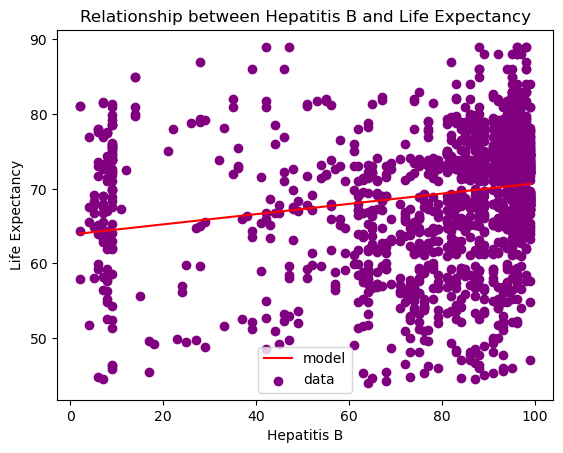

In [639]:
reg_linear(hepatitis_b, life_expectancy, "Hepatitis B")

## Masalah 3

Berikan interval estimasi untuk membuat prediksi life expectancy atas suatu nilai aspek tertentu (misalnya persentase expenditure 90% ~ nilai yang dipilih bebas), dengan tingkat kepercayaan sebesar 95%.

In [640]:
def predict(x, y, predict, feature):
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    Sxx = np.sum((x-x_bar)**2)
    Sxy = np.sum((x-x_bar)*(y-y_bar))
    Syy = np.sum((y-y_bar)**2)

    print(f"Rataan x \t: {x_bar: .3f}")
    print(f"Rataan y \t: {y_bar: .3f}")
    print(f"Simpangan xx \t: {Sxx: .3f}")
    print(f"Simpangan xy \t: {Sxy: .3f}")
    print(f"Simpangan yy \t: {Syy: .3f}")

    b1 = Sxy/Sxx
    b0 = y_bar-b1*x_bar

    print(f"Nilai b0 \t: {b0: .3f}")
    print(f"Nilai b1 \t: {b1: .3f}")

    x_line = np.linspace(np.min(x), np.max(x), 100)
    y_line = b0 + b1 * x_line

    y_hat = b0 + b1 * x

    SSE = np.sum((y_hat - y)**2)
    SSR = np.sum((y_hat - y_bar)**2)
    SST = SSE + SSR

    print(f"SSE \t: {SSE: .3f}")
    print(f"SSR \t: {SSR: .3f}")
    print(f"SST \t: {SST: .3f}")

    rho = Sxy/np.sqrt(Sxx*Syy)
    R_square = rho**2
    MSE = 1/(n-2) * np.sum((y_hat-y)**2)
    RMSE = np.sqrt(MSE)

    print(f"rho \t: {rho: .3f}")
    print(f"R2 \t: {R_square: .3f}")
    print(f"MSE \t: {MSE: .3f}")
    print(f"RMSE \t: {RMSE: .3f}")

    alpha = 0.05

    sigma_alpha = RMSE * norm.ppf(1-alpha/2, 0, 1)
    
    x_line = np.linspace(np.min(x), np.max(x), 100)
    y_line = b0 + b1 * x_line

    y_low = y_line - sigma_alpha
    y_up = y_line + sigma_alpha
    

    plt.plot(x_line, y_line, label = "point estimator", c = "red")
    plt.plot(x_line, y_low, label = f"{1-alpha:.2%} interval estimator", c = "orange")
    plt.plot(x_line, y_up, label = f"{1-alpha:.2%} interval estimator", c = "orange")

    plt.scatter(x, y, label = "data")
    plt.xlabel(feature)
    plt.ylabel("Life Expectancy")
    plt.title(f"Relationship between {feature} & Life Expectancy")
    plt.legend()
    plt.show()

    x_predict = predict

    y_predict = b0 + b1 * x_predict

    print(f"x_predict \t: {x_predict: .3f}")
    print(f"y_predict \t: {y_predict: .3f}")

    y_pred_low = y_predict - sigma_alpha
    y_pred_up = y_predict + sigma_alpha

    print(f"\nWith confidence level {1-alpha:.2%},")
    print(f"y_predict \t: {y_pred_low: .3f} - {y_pred_up: .3f}")
    

Rataan x 	:  4.533
Rataan y 	:  69.302
Simpangan xx 	:  26754.232
Simpangan xy 	:  23523.538
Simpangan yy 	:  127529.311
Nilai b0 	:  65.317
Nilai b1 	:  0.879
SSE 	:  106846.347
SSR 	:  20682.965
SST 	:  127529.311
rho 	:  0.403
R2 	:  0.162
MSE 	:  64.873
RMSE 	:  8.054


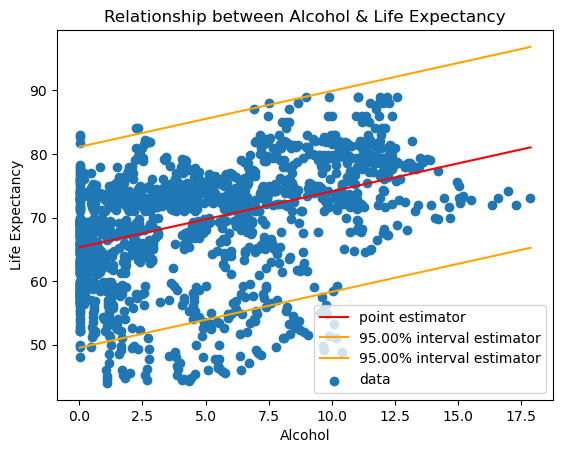

x_predict 	:  10.000
y_predict 	:  74.109

With confidence level 95.00%,
y_predict 	:  58.323 -  89.895


In [641]:
predict(alcohol, life_expectancy, 10.0, "Alcohol") #best prediction for life expectancy

Rataan x 	:  4.836
Rataan y 	:  4.230
Simpangan xx 	:  7134.691
Simpangan xy 	:  244.937
Simpangan yy 	:  30.016
Nilai b0 	:  4.064
Nilai b1 	:  0.034
SSE 	:  21.607
SSR 	:  8.409
SST 	:  30.016
rho 	:  0.529
R2 	:  0.280
MSE 	:  0.013
RMSE 	:  0.115


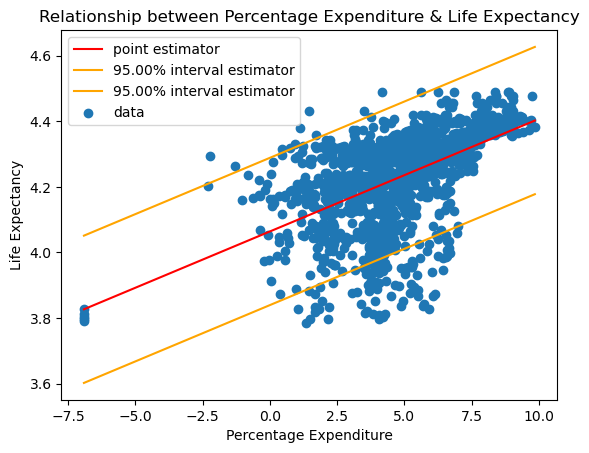

x_predict 	:  4.248
y_predict 	:  4.210

With confidence level 95.00%,
y_predict 	:  3.985 -  4.434


In [642]:
# predict(percentage_expenditure, life_expectancy, 70, "Percentage Expenditure")
predict(np.log(percentage_expenditure), np.log(life_expectancy), np.log(70), "Percentage Expenditure") #best r2
# predict(1/percentage_expenditure, 1/life_expectancy, 1/70, "Percentage Expenditure")
# predict(1/percentage_expenditure, life_expectancy, 1/70, "Percentage Expenditure")

Rataan x 	:  79.218
Rataan y 	:  69.302
Simpangan xx 	:  1080426.843
Simpangan xy 	:  74215.073
Simpangan yy 	:  127529.311
Nilai b0 	:  63.861
Nilai b1 	:  0.069
SSE 	:  122431.440
SSR 	:  5097.871
SST 	:  127529.311
rho 	:  0.200
R2 	:  0.040
MSE 	:  74.336
RMSE 	:  8.622


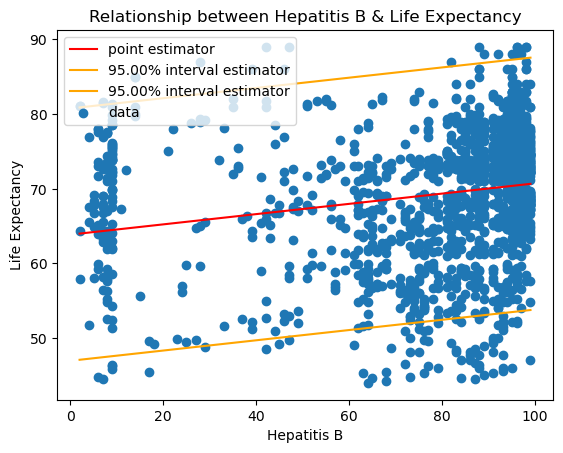

x_predict 	:  85.000
y_predict 	:  69.699

With confidence level 95.00%,
y_predict 	:  52.801 -  86.598


In [643]:
predict(hepatitis_b, life_expectancy, 85, "Hepatitis B")

Rataan x 	:  38.129
Rataan y 	:  69.302
Simpangan xx 	:  643099.649
Simpangan xy 	:  155230.391
Simpangan yy 	:  127529.311
Nilai b0 	:  60.099
Nilai b1 	:  0.241
SSE 	:  90060.041
SSR 	:  37469.270
SST 	:  127529.311
rho 	:  0.542
R2 	:  0.294
MSE 	:  54.681
RMSE 	:  7.395


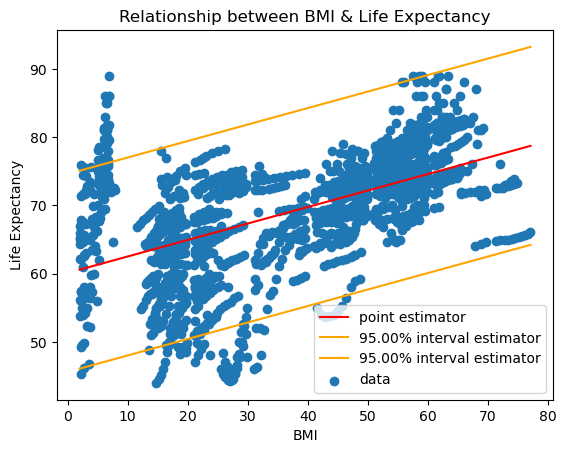

x_predict 	:  70.000
y_predict 	:  76.995

With confidence level 95.00%,
y_predict 	:  62.502 -  91.489


In [644]:
predict(bmi, life_expectancy, 70, "BMI")

## Masalah 4

Selidiki kembali model regresi linear untuk pasangan variabel yang sama, namun dipecah berdasarkan kategori negara (developed/developing). Berikan evaluasi kecocokan model dan buatlah suatu kesimpulan yang relevan.

In [645]:
def feature_status(data, feature ,status):
    df = pd.DataFrame(data)
    data_status = df.loc[df['Status']==status]

    if feature == "percentage expenditure":
        x = np.log(data_status[feature])
        y = np.log(data_status["Life expectancy "])
    else:
        x = data_status[feature]
        y = data_status["Life expectancy "]

    print(f"\nRelationship between {feature} & Life Expectancy in {status}")
    
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    Sxx = np.sum((x-x_bar)**2)
    Sxy = np.sum((x-x_bar)*(y-y_bar))
    Syy = np.sum((y-y_bar)**2)

    print(f"Rataan x \t: {x_bar: .3f}")
    print(f"Rataan y \t: {y_bar: .3f}")
    print(f"Simpangan xx \t: {Sxx: .3f}")
    print(f"Simpangan xy \t: {Sxy: .3f}")
    print(f"Simpangan yy \t: {Syy: .3f}")

    b1 = Sxy/Sxx
    b0 = y_bar-b1*x_bar

    print(f"Nilai b0 \t: {b0: .3f}")
    print(f"Nilai b1 \t: {b1: .3f}")

    x_line = np.linspace(np.min(x), np.max(x), 100)
    y_line = b0 + b1 * x_line

    y_hat = b0 + b1 * x

    SSE = np.sum((y_hat - y)**2)
    SSR = np.sum((y_hat - y_bar)**2)
    SST = SSE + SSR

    print(f"SSE \t: {SSE: .3f}")
    print(f"SSR \t: {SSR: .3f}")
    print(f"SST \t: {SST: .3f}")

    rho = Sxy/np.sqrt(Sxx*Syy)
    R_square = rho**2
    MSE = 1/(n-2) * np.sum((y_hat-y)**2)
    RMSE = np.sqrt(MSE)

    print(f"rho \t: {rho: .3f}")
    print(f"R2 \t: {R_square: .3f}")
    print(f"MSE \t: {MSE: .3f}")
    print(f"RMSE \t: {RMSE: .3f}")

    alpha = 0.05

    sigma_alpha = RMSE * norm.ppf(1-alpha/2, 0, 1)

    x_line = np.linspace(np.min(x), np.max(x), 100)
    y_line = b0 + b1 * x_line

    y_low = y_line - sigma_alpha
    y_up = y_line + sigma_alpha
    
    plt.plot(x_line, y_line, label = "point estimator", c = "red")
    plt.plot(x_line, y_low, label = f"{1-alpha:.2%} interval estimator", c = "orange")
    plt.plot(x_line, y_up, label = f"{1-alpha:.2%} interval estimator", c = "orange")

    plt.scatter(x, y, label = "data")
    plt.xlabel(feature)
    plt.ylabel("Life Expectancy")
    plt.title(f"Relationship between {feature} & Life Expectancy in {status}")
    plt.legend()
    plt.show()
    


Relationship between Alcohol & Life Expectancy in Developing
Rataan x 	:  3.518
Rataan y 	:  67.687
Simpangan xx 	:  15608.370
Simpangan xy 	:  7975.226
Simpangan yy 	:  98123.375
Nilai b0 	:  65.890
Nilai b1 	:  0.511
SSE 	:  94048.367
SSR 	:  4075.007
SST 	:  98123.375
rho 	:  0.204
R2 	:  0.042
MSE 	:  57.103
RMSE 	:  7.557


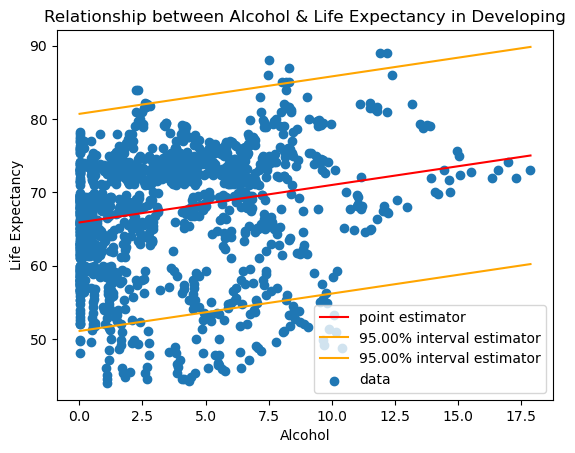


Relationship between  BMI  & Life Expectancy in Developing
Rataan x 	:  35.685
Rataan y 	:  67.687
Simpangan xx 	:  510456.968
Simpangan xy 	:  117196.581
Simpangan yy 	:  98123.375
Nilai b0 	:  59.494
Nilai b1 	:  0.230
SSE 	:  71216.036
SSR 	:  26907.339
SST 	:  98123.375
rho 	:  0.524
R2 	:  0.274
MSE 	:  43.240
RMSE 	:  6.576


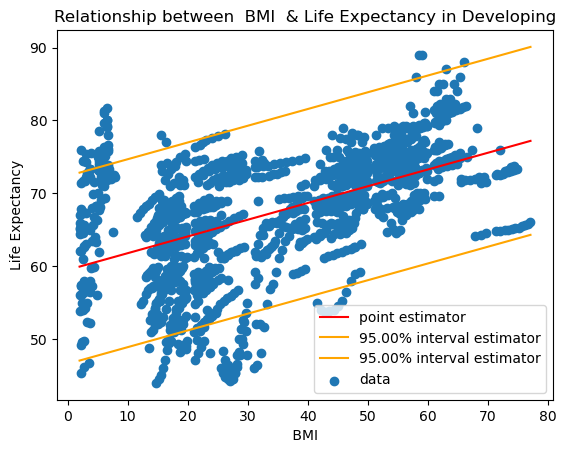


Relationship between Hepatitis B & Life Expectancy in Developing
Rataan x 	:  77.728
Rataan y 	:  67.687
Simpangan xx 	:  966760.743
Simpangan xy 	:  52711.655
Simpangan yy 	:  98123.375
Nilai b0 	:  63.449
Nilai b1 	:  0.055
SSE 	:  95249.325
SSR 	:  2874.050
SST 	:  98123.375
rho 	:  0.171
R2 	:  0.029
MSE 	:  57.832
RMSE 	:  7.605


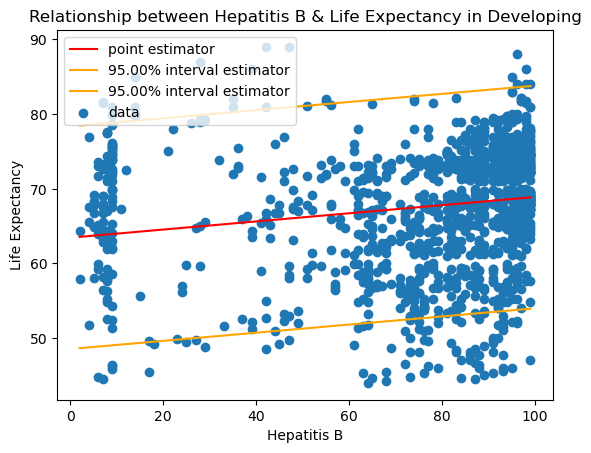


Relationship between percentage expenditure & Life Expectancy in Developing
Rataan x 	:  4.491
Rataan y 	:  4.207
Simpangan xx 	:  5250.391
Simpangan xy 	:  158.694
Simpangan yy 	:  24.190
Nilai b0 	:  4.071
Nilai b1 	:  0.030
SSE 	:  19.393
SSR 	:  4.797
SST 	:  24.190
rho 	:  0.445
R2 	:  0.198
MSE 	:  0.012
RMSE 	:  0.109


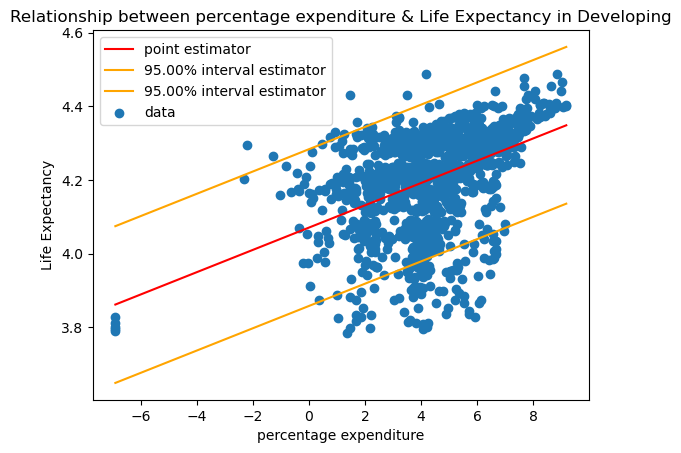

In [646]:
feature_status(data, 'Alcohol', 'Developing')
feature_status(data, ' BMI ', 'Developing')
feature_status(data, 'Hepatitis B', 'Developing')
feature_status(data, 'percentage expenditure', 'Developing')


Relationship between Alcohol & Life Expectancy in Developed
Rataan x 	:  10.436
Rataan y 	:  78.692
Simpangan xx 	:  1262.884
Simpangan xy 	: -171.747
Simpangan yy 	:  4401.303
Nilai b0 	:  80.111
Nilai b1 	: -0.136
SSE 	:  4377.947
SSR 	:  23.357
SST 	:  4401.303
rho 	: -0.073
R2 	:  0.005
MSE 	:  2.658
RMSE 	:  1.630


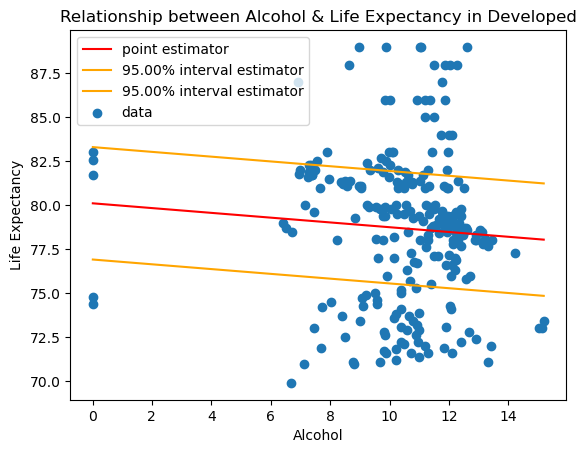


Relationship between  BMI  & Life Expectancy in Developed
Rataan x 	:  52.337
Rataan y 	:  78.692
Simpangan xx 	:  75387.183
Simpangan xy 	:  196.624
Simpangan yy 	:  4401.303
Nilai b0 	:  78.555
Nilai b1 	:  0.003
SSE 	:  4400.791
SSR 	:  0.513
SST 	:  4401.303
rho 	:  0.011
R2 	:  0.000
MSE 	:  2.672
RMSE 	:  1.635


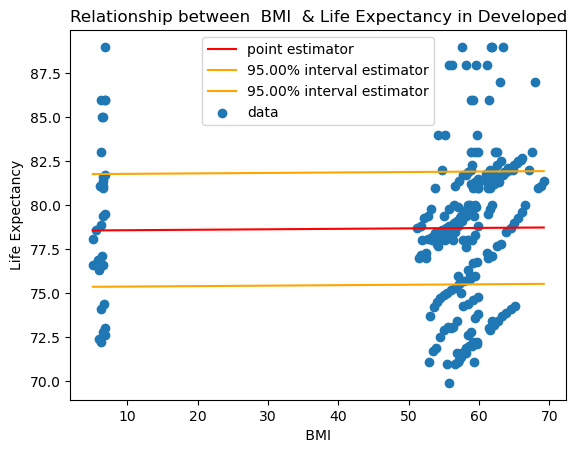


Relationship between Hepatitis B & Life Expectancy in Developed
Rataan x 	:  87.880
Rataan y 	:  78.692
Simpangan xx 	:  92383.525
Simpangan xy 	: -1565.240
Simpangan yy 	:  4401.303
Nilai b0 	:  80.181
Nilai b1 	: -0.017
SSE 	:  4374.784
SSR 	:  26.520
SST 	:  4401.303
rho 	: -0.078
R2 	:  0.006
MSE 	:  2.656
RMSE 	:  1.630


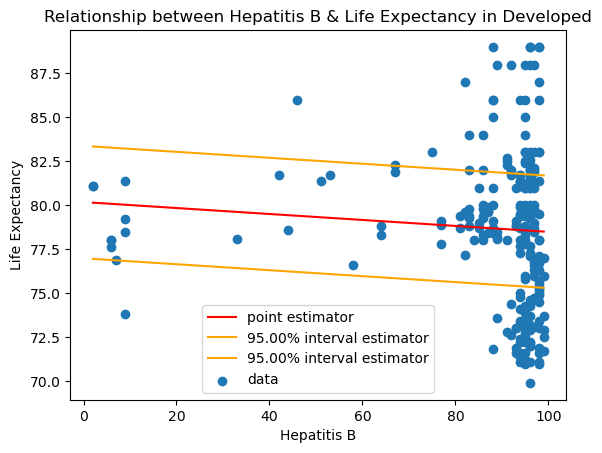


Relationship between percentage expenditure & Life Expectancy in Developed
Rataan x 	:  6.840
Rataan y 	:  4.364
Simpangan xx 	:  744.914
Simpangan xy 	:  9.893
Simpangan yy 	:  0.710
Nilai b0 	:  4.273
Nilai b1 	:  0.013
SSE 	:  0.579
SSR 	:  0.131
SST 	:  0.710
rho 	:  0.430
R2 	:  0.185
MSE 	:  0.000
RMSE 	:  0.019


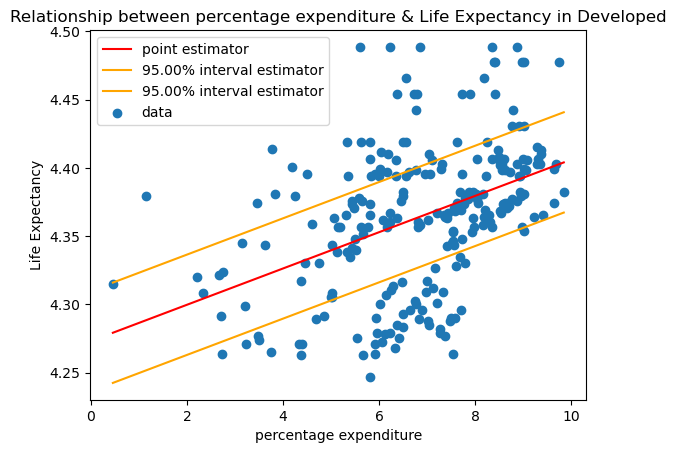

In [647]:
feature_status(data, 'Alcohol', 'Developed')
feature_status(data, ' BMI ', 'Developed')
feature_status(data, 'Hepatitis B', 'Developed')
feature_status(data, 'percentage expenditure', 'Developed')

## Masalah 5

Berikan kesimpulan mengenai bagaimana keempat aspek pada pengantar tersebut mempengaruhi/tidak mempengaruhi life expectancy.

## Komitmen Integritas
“Di hadapan TUHAN yang hidup, saya menegaskan bahwa saya tidak memberikan maupun menerima bantuan apapun – baik lisan, tulisan, maupun elektronik – di dalam ujian ini selain daripada apa yang telah diizinkan oleh pengajar, dan tidak akan menyebarkan baik soal maupun jawaban ujian kepada pihak lain”